In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score, classification_report, auc
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [99]:
df = pd.read_csv("../dataset/UCI/hungarian.csv")
df_combine = pd.read_csv("../dataset/UCI/heart_combined.csv")

In [100]:
df = df.replace("?", pd.NA)

df = df.apply(pd.to_numeric, errors='coerce')

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       294 non-null    int64  
 1   sex       294 non-null    int64  
 2   cp        294 non-null    int64  
 3   trestbps  293 non-null    float64
 4   chol      271 non-null    float64
 5   fbs       286 non-null    float64
 6   restecg   293 non-null    float64
 7   thalach   293 non-null    float64
 8   exang     293 non-null    float64
 9   oldpeak   294 non-null    float64
 10  slope     104 non-null    float64
 11  ca        3 non-null      float64
 12  thal      28 non-null     float64
 13  target    294 non-null    int64  
dtypes: float64(10), int64(4)
memory usage: 32.3 KB


In [102]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,294.000000,294.000000,294.000000,293.000000,271.000000,286.000000,293.000000,293.000000,293.000000,294.000000,104.000000,3.0,28.000000,294.000000
mean,47.826531,0.724490,2.982993,132.583618,250.848708,0.069930,0.218430,139.129693,0.303754,0.586054,1.894231,0.0,5.642857,0.360544
std,7.811812,0.447533,0.965117,17.626568,67.657711,0.255476,0.460868,23.589749,0.460665,0.908648,0.338995,0.0,1.615074,0.480977
min,28.000000,0.000000,1.000000,92.000000,85.000000,0.000000,0.000000,82.000000,0.000000,0.000000,1.000000,0.0,3.000000,0.000000
25%,42.000000,0.000000,2.000000,120.000000,209.000000,0.000000,0.000000,122.000000,0.000000,0.000000,2.000000,0.0,5.250000,0.000000
50%,49.000000,1.000000,3.000000,130.000000,243.000000,0.000000,0.000000,140.000000,0.000000,0.000000,2.000000,0.0,6.000000,0.000000
75%,54.000000,1.000000,4.000000,140.000000,282.500000,0.000000,0.000000,155.000000,1.000000,1.000000,2.000000,0.0,7.000000,1.000000
max,66.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,190.000000,1.000000,5.000000,3.000000,0.0,7.000000,1.000000


In [103]:
df.duplicated().sum()

np.int64(1)

In [104]:
df.isnull().sum()

age           0
sex           0
cp            0
trestbps      1
chol         23
fbs           8
restecg       1
thalach       1
exang         1
oldpeak       0
slope       190
ca          291
thal        266
target        0
dtype: int64

In [105]:
df['target'].value_counts()

target
0    188
1    106
Name: count, dtype: int64

In [106]:
df['target'] = np.where(df['target'] == 0, 0, 1)

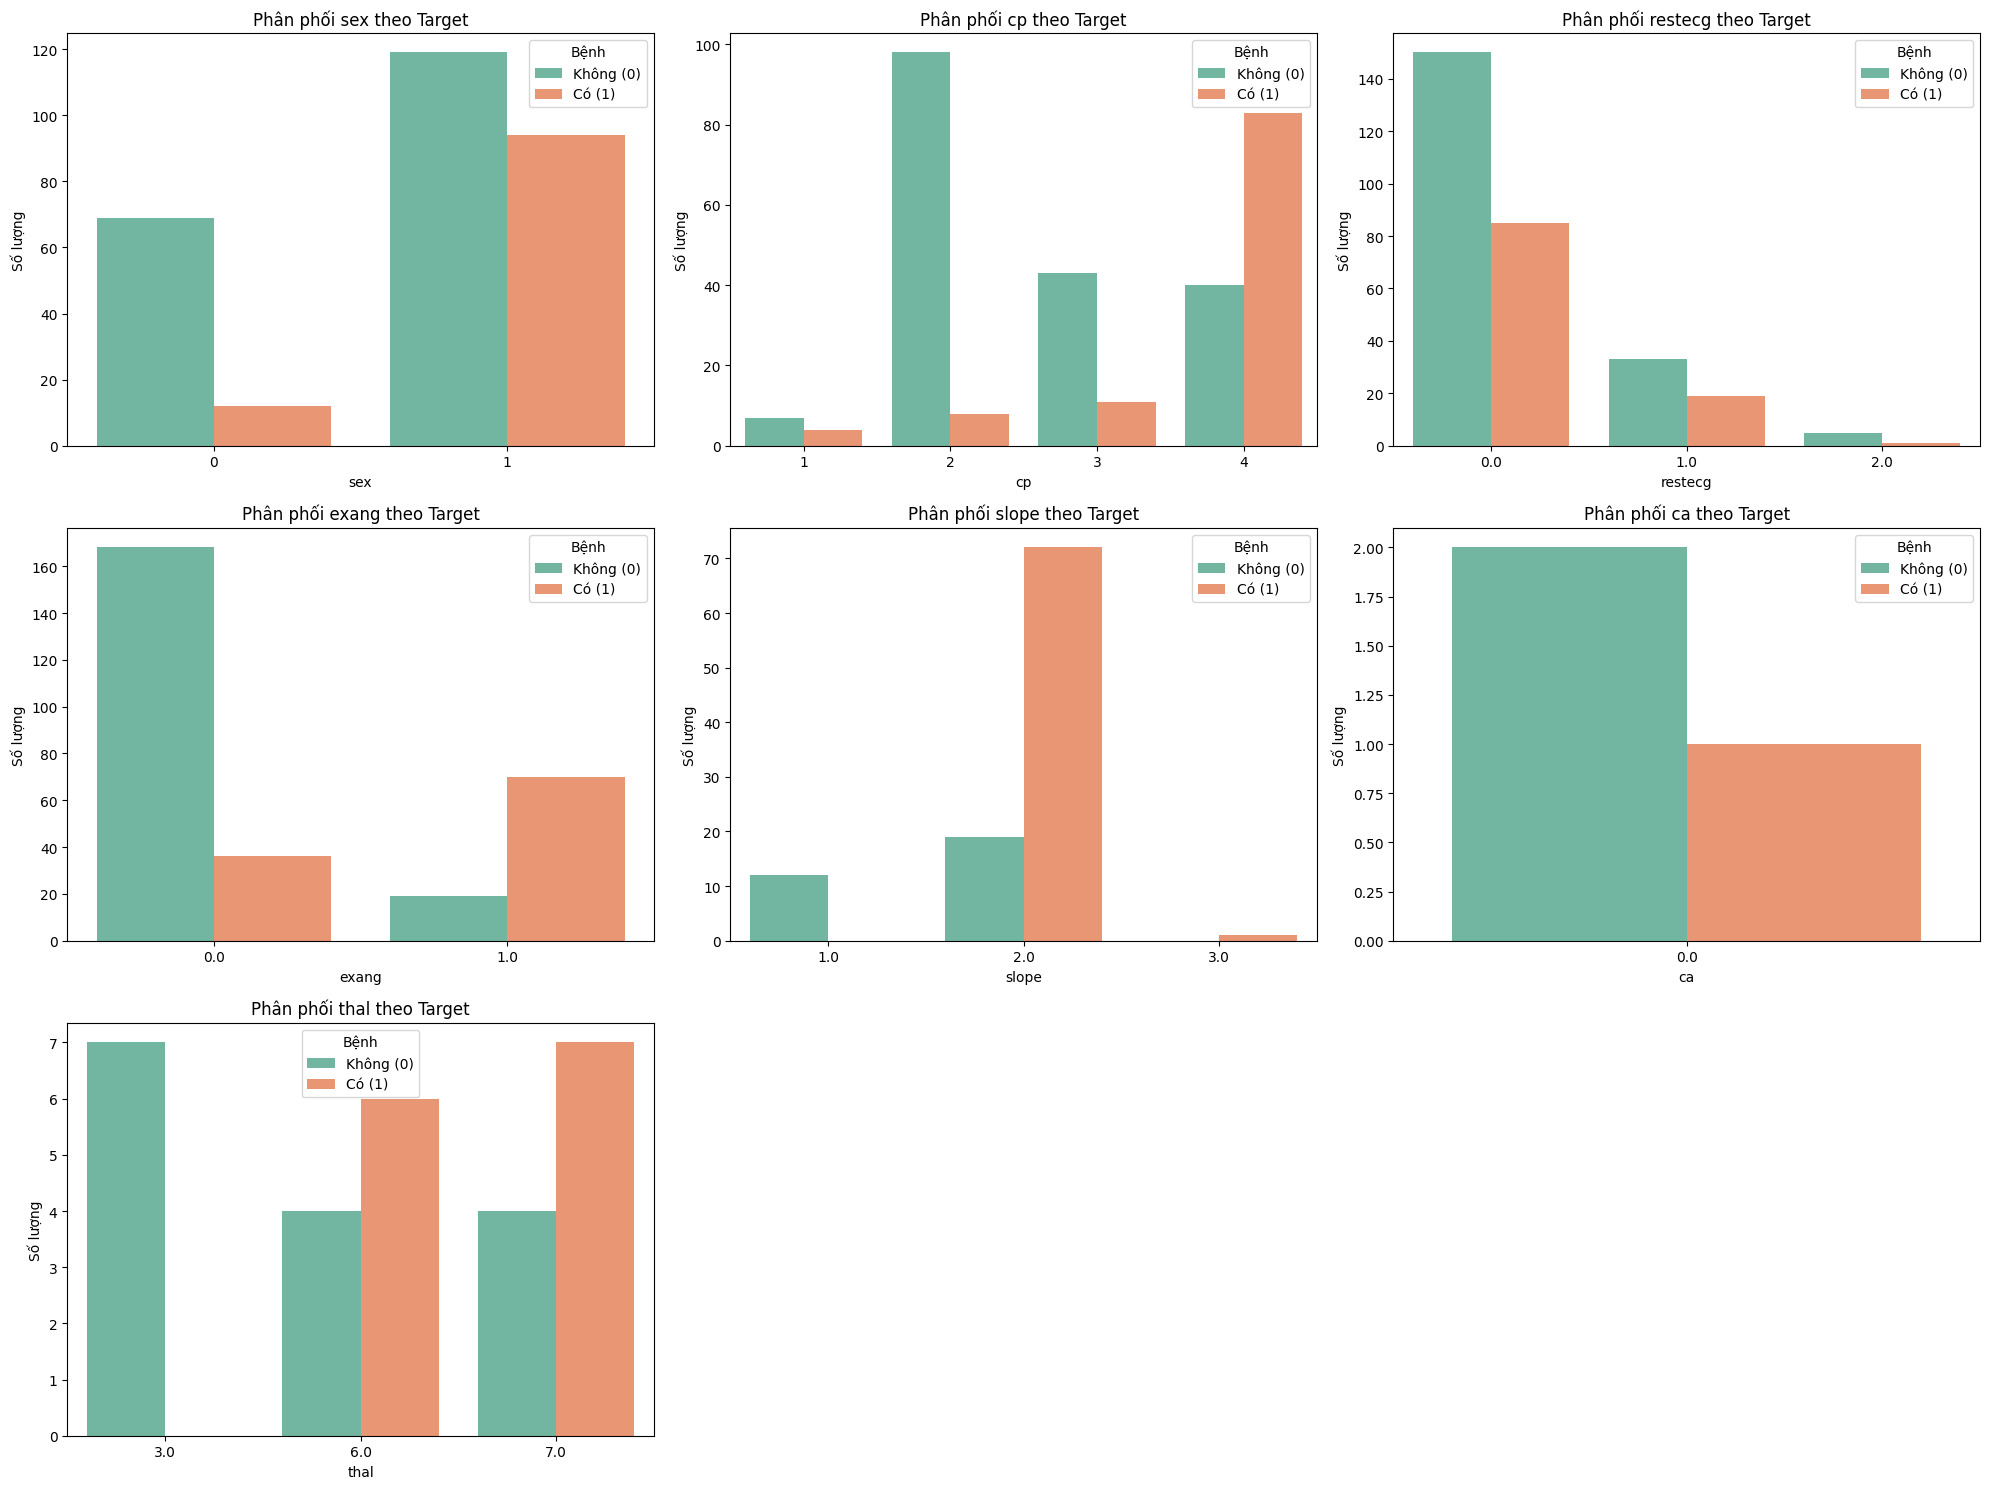

In [107]:
categorical_features = ['sex', 'cp', 'restecg', 'exang', 'slope', 'ca', 'thal']

plt.figure(figsize=(20, 15))

for i, col in enumerate(categorical_features, 1):
    plt.subplot(3, 3, i)
    sns.countplot(x=col, hue='target', data=df, palette='Set2')
    plt.title(f'Phân phối {col} theo Target')
    plt.xlabel(col)
    plt.ylabel('Số lượng')
    plt.legend(title='Bệnh', labels=['Không (0)', 'Có (1)'])

plt.tight_layout()
plt.show()

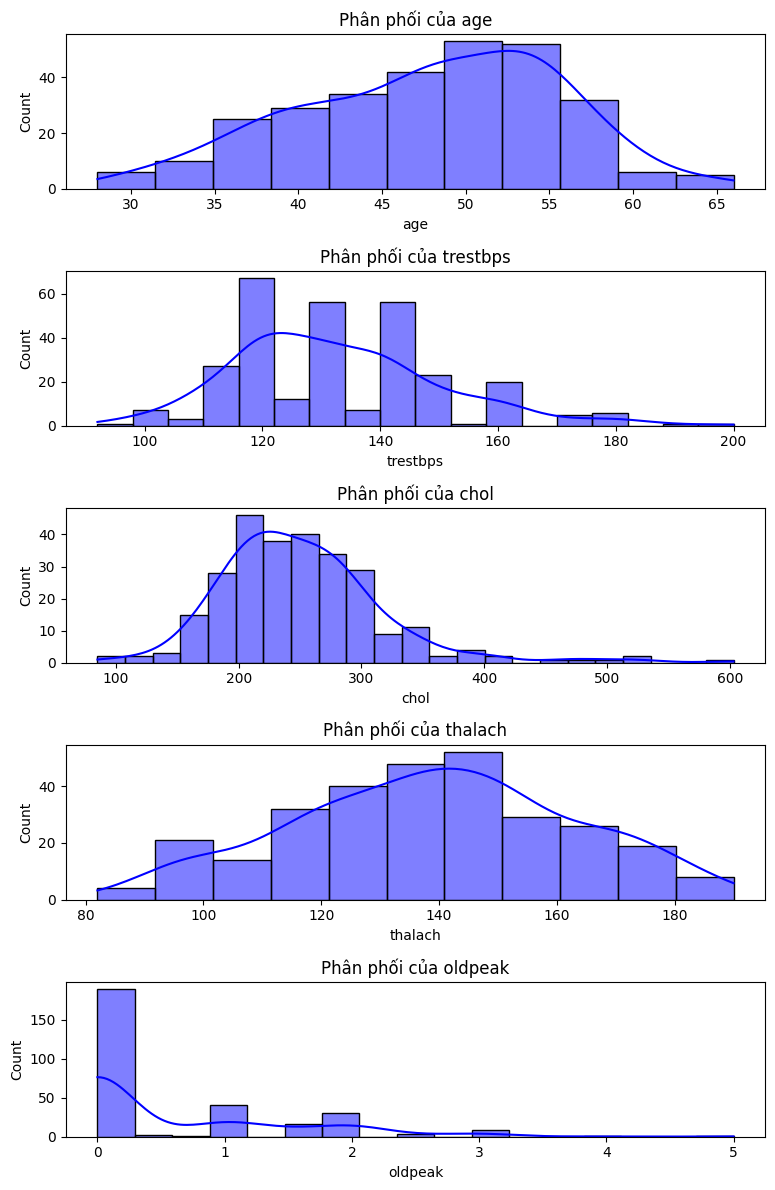

In [108]:
continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

plt.figure(figsize=(15, 12))
for i, col in enumerate(continuous_features):
    plt.subplot(len(continuous_features), 2, 2*i + 1)
    sns.histplot(df[col], kde=True, color='blue')
    plt.title(f'Phân phối của {col}')
    

plt.tight_layout()
plt.show()

COMBINE

In [109]:
df_combine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   age       920 non-null    int64 
 1   sex       920 non-null    int64 
 2   cp        920 non-null    int64 
 3   trestbps  920 non-null    object
 4   chol      920 non-null    object
 5   fbs       920 non-null    object
 6   restecg   920 non-null    object
 7   thalach   920 non-null    object
 8   exang     920 non-null    object
 9   oldpeak   920 non-null    object
 10  slope     920 non-null    object
 11  ca        920 non-null    object
 12  thal      920 non-null    object
 13  target    920 non-null    int64 
 14  source    920 non-null    object
dtypes: int64(4), object(11)
memory usage: 107.9+ KB


In [110]:
df_combine = df_combine.drop('source',axis=1, inplace=False)
df_combine = df_combine.replace("?", pd.NA)

df_combine = df_combine.apply(pd.to_numeric, errors='coerce')

In [111]:
df_combine.duplicated().sum()

np.int64(2)

In [112]:
df_combine.drop_duplicates()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67,1,4,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67,1,4,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37,1,3,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41,0,2,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,54,0,4,127.0,333.0,1.0,1.0,154.0,0.0,0.0,NaN,NaN,NaN,1
916,62,1,1,NaN,139.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,0
917,55,1,4,122.0,223.0,1.0,1.0,100.0,0.0,0.0,NaN,NaN,6.0,2
918,58,1,4,NaN,385.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,0


In [113]:
df_combine['target'].value_counts()

target
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

In [114]:
df_combine['target'] = np.where(df_combine['target'] == 0, 0, 1)

In [115]:
df_combine['target'].value_counts()

target
1    509
0    411
Name: count, dtype: int64

In [116]:
df_combine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    int64  
 1   sex       920 non-null    int64  
 2   cp        920 non-null    int64  
 3   trestbps  861 non-null    float64
 4   chol      890 non-null    float64
 5   fbs       830 non-null    float64
 6   restecg   918 non-null    float64
 7   thalach   865 non-null    float64
 8   exang     865 non-null    float64
 9   oldpeak   858 non-null    float64
 10  slope     611 non-null    float64
 11  ca        309 non-null    float64
 12  thal      434 non-null    float64
 13  target    920 non-null    int64  
dtypes: float64(10), int64(4)
memory usage: 100.8 KB


In [117]:
df_combine.tail(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
910,51,0,4,114.0,258.0,1.0,2.0,96.0,0.0,1.0,1.0,NaN,NaN,0
911,62,1,4,160.0,254.0,1.0,1.0,108.0,1.0,3.0,2.0,NaN,NaN,1
912,53,1,4,144.0,300.0,1.0,1.0,128.0,1.0,1.5,2.0,NaN,NaN,1
913,62,1,4,158.0,170.0,0.0,1.0,138.0,1.0,0.0,NaN,NaN,NaN,1
914,46,1,4,134.0,310.0,0.0,0.0,126.0,0.0,0.0,NaN,NaN,3.0,1
915,54,0,4,127.0,333.0,1.0,1.0,154.0,0.0,0.0,NaN,NaN,NaN,1
916,62,1,1,NaN,139.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,0
917,55,1,4,122.0,223.0,1.0,1.0,100.0,0.0,0.0,NaN,NaN,6.0,1
918,58,1,4,NaN,385.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,0
919,62,1,2,120.0,254.0,0.0,2.0,93.0,1.0,0.0,NaN,NaN,NaN,1


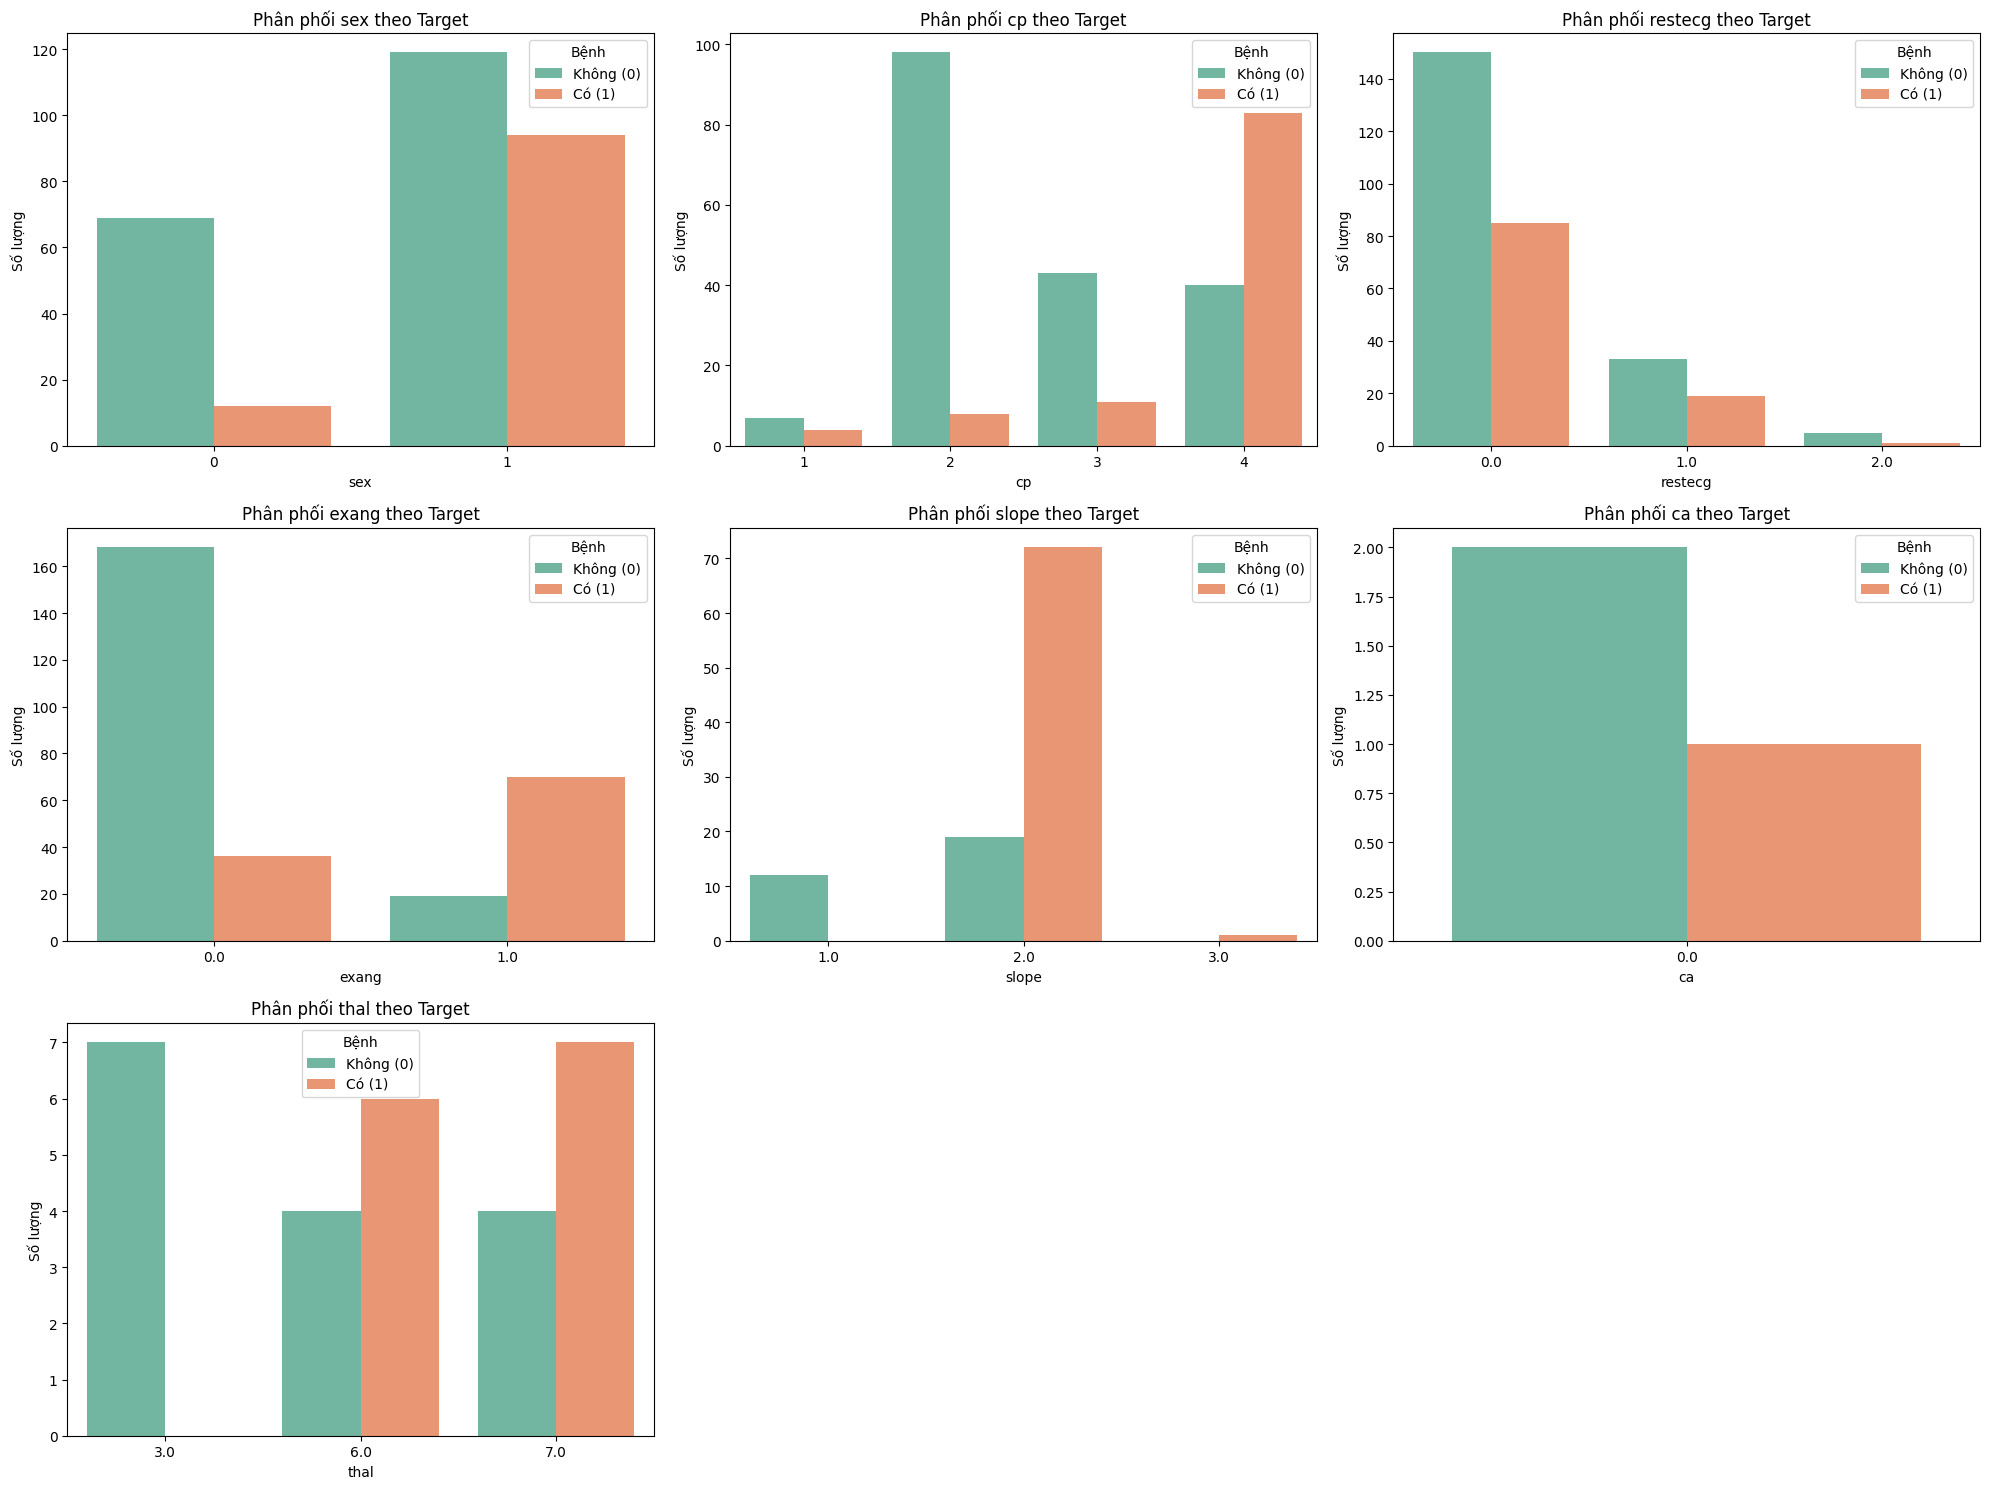

In [118]:
categorical_features = ['sex', 'cp', 'restecg', 'exang', 'slope', 'ca', 'thal']

plt.figure(figsize=(20, 15))

for i, col in enumerate(categorical_features, 1):
    plt.subplot(3, 3, i)
    sns.countplot(x=col, hue='target', data=df, palette='Set2')
    plt.title(f'Phân phối {col} theo Target')
    plt.xlabel(col)
    plt.ylabel('Số lượng')
    plt.legend(title='Bệnh', labels=['Không (0)', 'Có (1)'])

plt.tight_layout()
plt.show()

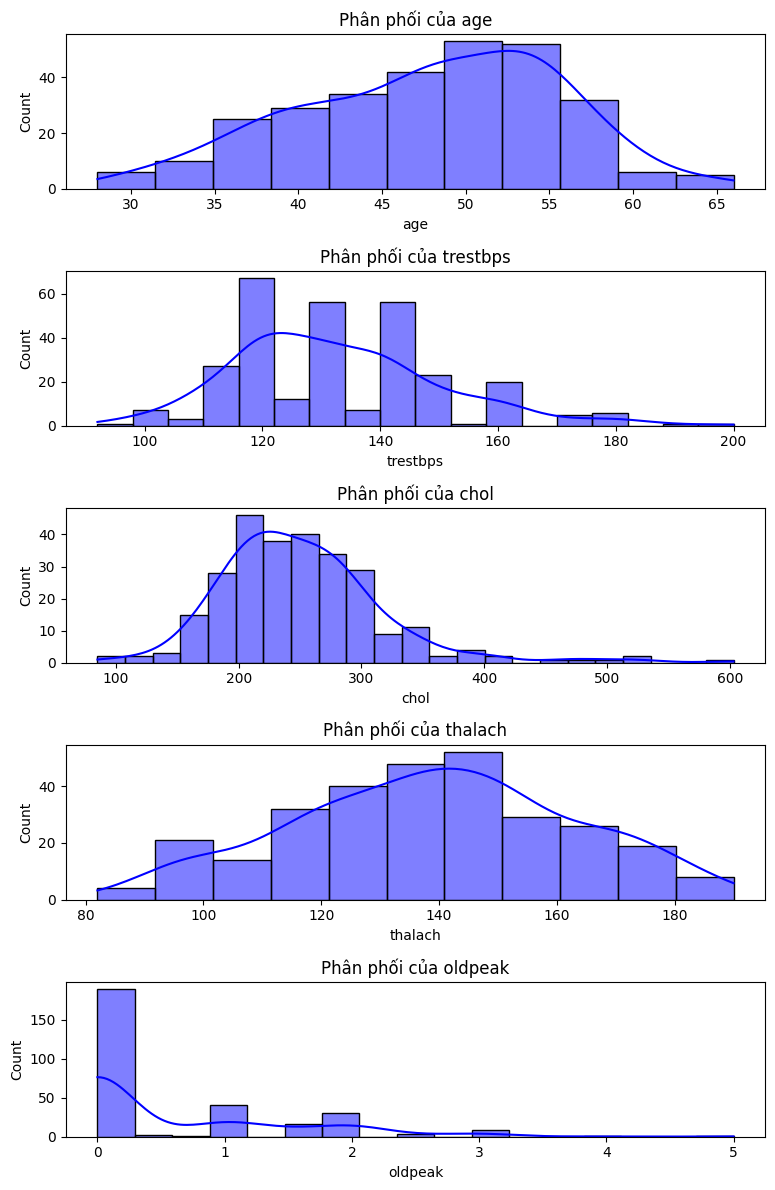

In [119]:
continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

plt.figure(figsize=(15, 12))
for i, col in enumerate(continuous_features):
    plt.subplot(len(continuous_features), 2, 2*i + 1)
    sns.histplot(df[col], kde=True, color='blue')
    plt.title(f'Phân phối của {col}')
    

plt.tight_layout()
plt.show()